# Comparison of SHAP, LIME, IG #

## Load all data into dataframe ##

In [9]:
import os 

print(f"I am looking in: {os.getcwd()}")
print(f"Folders I see: {os.listdir('.')}")

I am looking in: c:\Users\maewa\Coding\IntProjectII\IMCS3020U_Project_TBA\notebooks
Folders I see: ['comparison_analysis.ipynb', 'IG.ipynb', 'LIME.ipynb', 'SHAP.ipynb']


In [11]:
import pandas as pd 
import os

base_path = "../data/importance_scores"
methods = ["lime", "shap"]

dfs = {}

for method in methods:
    folder_path = os.path.join(base_path, method)
    all_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]
    dfs[method] = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True) 

## Fix typo in column name


In [ ]:
# Fixes typo by taking data from 'importantce score' column, moving it to 'importance score' and deleting the column
for method in dfs: 
    df = dfs[method] 

    if 'importantce_score' in df.columns:
        df['importance_score'] = df['importance_score'].fillna(df['importantce_score'])

        df.drop(columns=['importantce_score'], inplace=True)
        print(f"Fixed typo for {method}")

for method, df in dfs.items():
    print(f"{method} columns: {list(df.columns)}")

if 'lime' in dfs:
    display(dfs['lime'].head())

,word,importance_score,method,label
0,Shut,0.552417,LIME,anger
1,IDIOT,0.491901,LIME,anger
2,curse,0.469908,LIME,anger
3,wtf,0.430794,LIME,anger
4,Fuck,0.389343,LIME,anger


lime columns: ['word', 'importance_score', 'method', 'label']
shap columns: ['word', 'importance_score', 'method', 'label']


,word,importance_score,method,label
0,Shut,0.552417,LIME,anger
1,IDIOT,0.491901,LIME,anger
2,curse,0.469908,LIME,anger
3,wtf,0.430794,LIME,anger
4,Fuck,0.389343,LIME,anger


In [22]:
if 'shap' in dfs:
    display(dfs['shap'].head())

,word,importance_score,method,label
0,NaN,3.493011e-05,SHAP,anger
1,,4.394678e-09,SHAP,anger
2,!,5.582918e-03,SHAP,anger
3,!,4.526781e-03,SHAP,anger
4,"""",7.387268e-04,SHAP,anger


## Concatenate into comparison dataframe

In [24]:
main_df = pd.concat(dfs.values(), ignore_index=True)

anger_comparison = main_df[main_df['label'] == 'anger'].groupby(['word', 'method'])['importance_score'].mean().unstack()
print(anger_comparison.head(100))

method      LIME          SHAP
word                          
             NaN  4.394678e-09
!            NaN  5.582918e-03
!            NaN  4.526781e-03
"            NaN  7.387268e-04
"            NaN  2.576029e-03
...          ...           ...
55           NaN -1.572784e-03
6      -0.000718  2.128069e-04
6            NaN  2.164987e-04
600    -0.002626           NaN
600          NaN  1.218402e-03

[100 rows x 2 columns]


## Create comparison dataframe that ignores punctuation

In [ ]:
comparison_df = main_df[main_df['word'].str.contains(r'[a-zA-Z]', na=False)].copy()

# Plot comparisons

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

label_str = 'joy'

# make a dataframe for a label, filtering for rows that contain at least a letter
label_df = main_df[(main_df['label'] == label_str) &
                   (main_df['word'].str.contains(f'[a-zA-Z]', na=False))].copy()

# pivot df so SHAP and LIME are columns
plot_df = label_df.pivot(index=['word', 'label'], columns='method', values='importance_score')
plot_df = plot_df.reset_index()

# drops rows where one method is missing a value
plot_df = plot_df.dropna(subset=['LIME', 'SHAP'])

print(plot_df.head())


method        word label      LIME      SHAP
12               A   joy -0.000239  0.000337
16         ADOPTED   joy -0.175426 -0.106312
36      Absolutely   joy  0.081504  0.082367
42          Agreed   joy  0.203397  0.259015
47           Alpha   joy  0.010869  0.001107


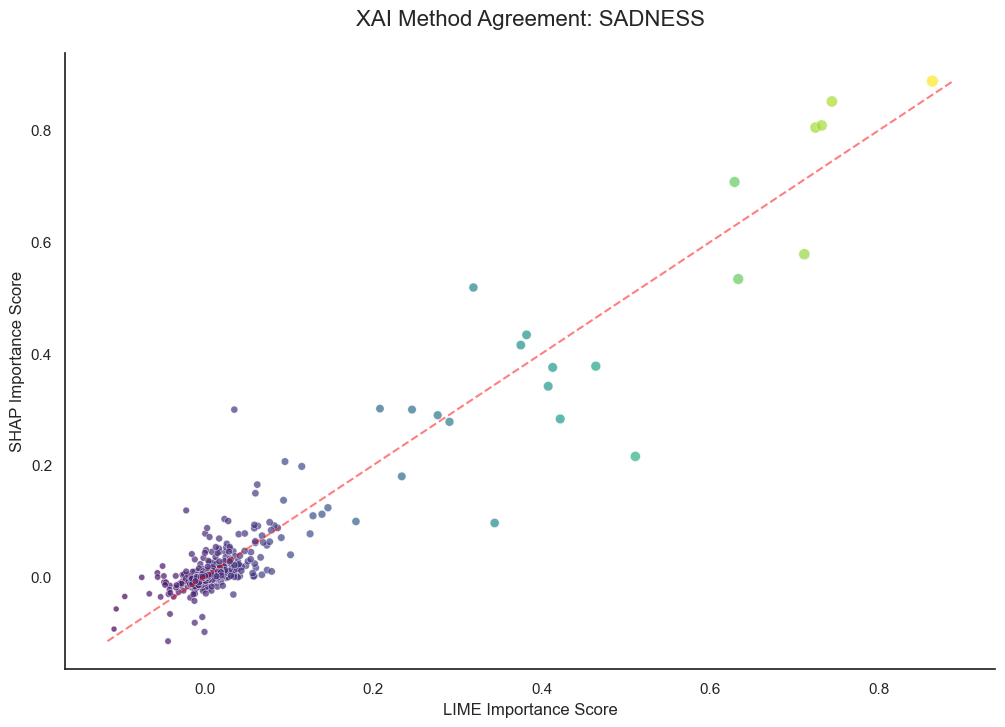

In [42]:
plt.figure(figsize=(12,8))
sns.set_theme(style='white')

scatter = sns.scatterplot(
    data=plot_df,
    x='LIME',
    y='SHAP',
    size='LIME',
    hue='LIME',
    palette='viridis',
    alpha=0.7,
    legend=False
)

# adds agreement line
min_val = min(plot_df['LIME'].min(), plot_df['SHAP'].min())
max_val = max(plot_df['LIME'].max(), plot_df['SHAP'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', alpha=0.5, label='Agreement')

top_words = plot_df.sort_values(by='LIME', ascending=False).head(10)

""" for i, row in top_words.iterrows():
    plt.text(
        row['LIME'] + (max_val+0.01),
        row['SHAP'] + (max_val*0.01),
        row['word'],
        fontsize=11,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1)
    ) """

plt.title(f"XAI Method Agreement: {plot_df['label'].iloc[0].upper()}", fontsize=16, pad=20)
plt.xlabel("LIME Importance Score", fontsize=12)
plt.ylabel("SHAP Importance Score", fontsize=12)

sns.despine()
plt.show()

## Horizontal Bar Charts comparing top n words

C:\Users\maewa\AppData\Local\Temp\ipykernel_39100\930207030.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_lime, x='LIME', y='word', ax=ax1, palette='Blues_r')
C:\Users\maewa\AppData\Local\Temp\ipykernel_39100\930207030.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_shap, x='SHAP', y='word', ax=ax2, palette='Greens_r')


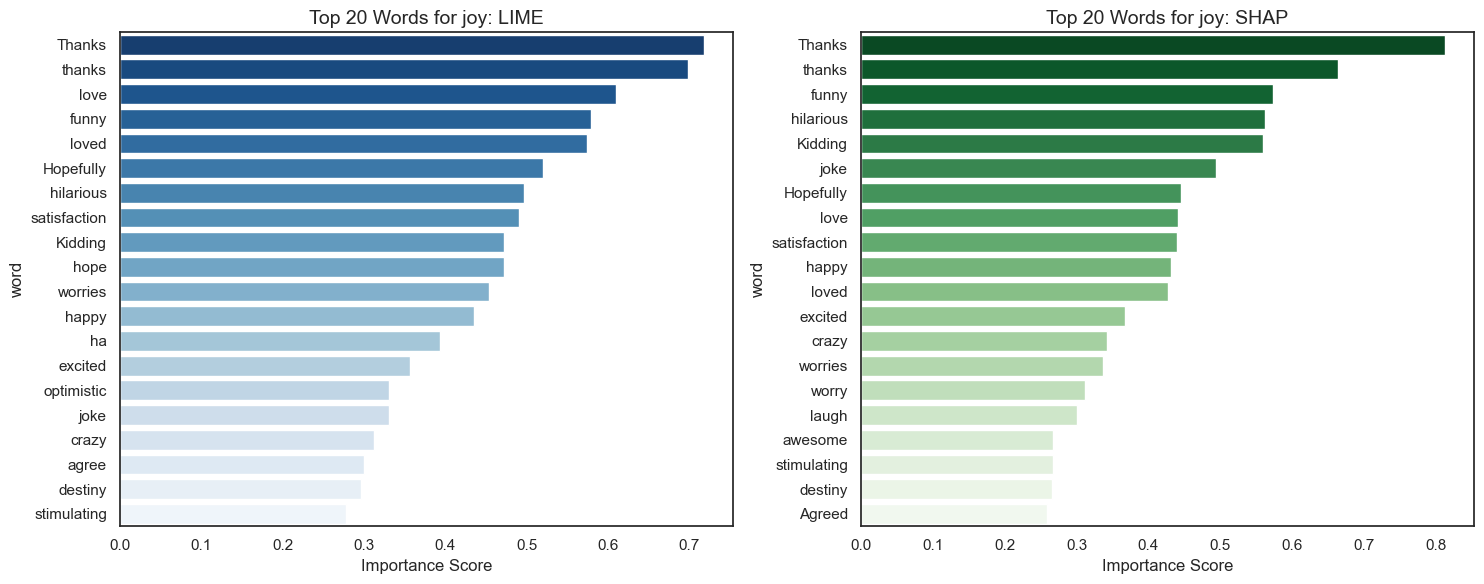

In [52]:
top_n = 20

top_lime = plot_df.sort_values('LIME', ascending=False).head(top_n)
top_shap = plot_df.sort_values('SHAP', ascending=False).head(top_n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6), sharey=False)

sns.barplot(data=top_lime, x='LIME', y='word', ax=ax1, palette='Blues_r')
ax1.set_title(f"Top {top_n} Words for {label_str}: LIME", fontsize=14)
ax1.set_xlabel("Importance Score")

sns.barplot(data=top_shap, x='SHAP', y='word', ax=ax2, palette='Greens_r')
ax2.set_title(f"Top {top_n} Words for {label_str}: SHAP", fontsize=14)
ax2.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()
